In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset source

Lichman, M. (2013). UCI Machine Learning Repository [http://archive.ics.uci.edu/ml]. Irvine, CA: University of California, School of Information and Computer Science.

In [2]:
df = pd.read_csv(r"/kaggle/input/datasets/organizations/uciml/default-of-credit-card-clients-dataset/UCI_Credit_Card.csv")

In [3]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


- ID: ID of each client
- LIMIT_BAL: Amount of given credit in NT dollars (includes individual and family/supplementary credit)
- SEX: Gender (1=male, 2=female)
- EDUCATION: (1=graduate school, 2=university, 3=high school, 4=others, 5=unknown, 6=unknown)
- MARRIAGE: Marital status (1=married, 2=single, 3=others)
- AGE: Age in years
- PAY_0: Repayment status in September, 2005 (-1=pay duly, 1=payment delay for one month, 2=payment delay for two months, … 8=payment delay for eight months, 9=payment delay for nine months and above)
- PAY_2: Repayment status in August, 2005 (scale same as above)
- PAY_3: Repayment status in July, 2005 (scale same as above)
- PAY_4: Repayment status in June, 2005 (scale same as above)
- PAY_5: Repayment status in May, 2005 (scale same as above)
- PAY_6: Repayment status in April, 2005 (scale same as above)
- BILL_AMT1: Amount of bill statement in September, 2005 (NT dollar)
- BILL_AMT2: Amount of bill statement in August, 2005 (NT dollar)
- BILL_AMT3: Amount of bill statement in July, 2005 (NT dollar)
- BILL_AMT4: Amount of bill statement in June, 2005 (NT dollar)
- BILL_AMT5: Amount of bill statement in May, 2005 (NT dollar)
- BILL_AMT6: Amount of bill statement in April, 2005 (NT dollar)
- PAY_AMT1: Amount of previous payment in September, 2005 (NT dollar)
- PAY_AMT2: Amount of previous payment in August, 2005 (NT dollar)
- PAY_AMT3: Amount of previous payment in July, 2005 (NT dollar)
- PAY_AMT4: Amount of previous payment in June, 2005 (NT dollar)
- PAY_AMT5: Amount of previous payment in May, 2005 (NT dollar)
- PAY_AMT6: Amount of previous payment in April, 2005 (NT dollar)
- default.payment.next.month: Default payment (1=yes, 0=no)

# Target

default.payment.next.month --> After observing the last 6 months of behavior, will the customer fail to repay their credit card debt in the following month?

In [4]:
df.shape

(30000, 25)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [6]:
df.describe().round(2)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,...,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00
mean,15000.50,167484.32,1.60,1.85,1.55,35.49,-0.02,-0.13,-0.17,-0.22,...,43262.95,40311.40,38871.76,5663.58,5921.16,5225.68,4826.08,4799.39,5215.50,0.22
std,8660.40,129747.66,0.49,0.79,0.52,9.22,1.12,1.20,1.20,1.17,...,64332.86,60797.16,59554.11,16563.28,23040.87,17606.96,15666.16,15278.31,17777.47,0.42
min,1.00,10000.00,1.00,0.00,0.00,21.00,-2.00,-2.00,-2.00,-2.00,...,-170000.00,-81334.00,-339603.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,7500.75,50000.00,1.00,1.00,1.00,28.00,-1.00,-1.00,-1.00,-1.00,...,2326.75,1763.00,1256.00,1000.00,833.00,390.00,296.00,252.50,117.75,0.00
50%,15000.50,140000.00,2.00,2.00,2.00,34.00,0.00,0.00,0.00,0.00,...,19052.00,18104.50,17071.00,2100.00,2009.00,1800.00,1500.00,1500.00,1500.00,0.00
75%,22500.25,240000.00,2.00,2.00,2.00,41.00,0.00,0.00,0.00,0.00,...,54506.00,50190.50,49198.25,5006.00,5000.00,4505.00,4013.25,4031.50,4000.00,0.00
max,30000.00,1000000.00,2.00,6.00,3.00,79.00,8.00,8.00,8.00,8.00,...,891586.00,927171.00,961664.00,873552.00,1684259.00,896040.00,621000.00,426529.00,528666.00,1.00


Before modeling, we already know:

- Default is minority (22%)

- Payment delays likely strongest predictor

- Debt size varies massively

- Payment behavior matters more than raw money

- Some customers overpay (low risk signal)

In [7]:
df.groupby("PAY_0").agg(
    mean=('default.payment.next.month', 'mean'),
    count=('default.payment.next.month', 'count')
).round(2)

,mean,count
PAY_0,,
-2,0.13,2759
-1,0.17,5686
0,0.13,14737
1,0.34,3688
2,0.69,2667
3,0.76,322
4,0.68,76
5,0.50,26
6,0.55,11


When customers start missing payments the risk explodes.
Past delinquency predicts future default.

In [8]:
for col in ["PAY_0","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6"]:
    print(col)
    print(df.groupby(col)["default.payment.next.month"].mean().round(2))
    print()

PAY_0
PAY_0
-2    0.13
-1    0.17
 0    0.13
 1    0.34
 2    0.69
 3    0.76
 4    0.68
 5    0.50
 6    0.55
 7    0.78
 8    0.58
Name: default.payment.next.month, dtype: float64

PAY_2
PAY_2
-2    0.18
-1    0.16
 0    0.16
 1    0.18
 2    0.56
 3    0.62
 4    0.51
 5    0.60
 6    0.75
 7    0.60
 8    0.00
Name: default.payment.next.month, dtype: float64

PAY_3
PAY_3
-2    0.19
-1    0.16
 0    0.17
 1    0.25
 2    0.52
 3    0.57
 4    0.58
 5    0.57
 6    0.61
 7    0.81
 8    0.67
Name: default.payment.next.month, dtype: float64

PAY_4
PAY_4
-2    0.19
-1    0.16
 0    0.18
 1    0.50
 2    0.52
 3    0.61
 4    0.67
 5    0.51
 6    0.40
 7    0.83
 8    0.50
Name: default.payment.next.month, dtype: float64

PAY_5
PAY_5
-2    0.20
-1    0.16
 0    0.19
 2    0.54
 3    0.63
 4    0.61
 5    0.59
 6    0.75
 7    0.83
 8    1.00
Name: default.payment.next.month, dtype: float64

PAY_6
PAY_6
-2    0.20
-1    0.17
 0    0.19
 2    0.51
 3    0.64
 4    0.63
 5    0.54
 6    0

Default risk is strongly associated with repayment delay severity, with recent delinquency exhibiting substantially higher predictive power than older payment history, indicating temporal recency is a dominant risk signal.

<Axes: >

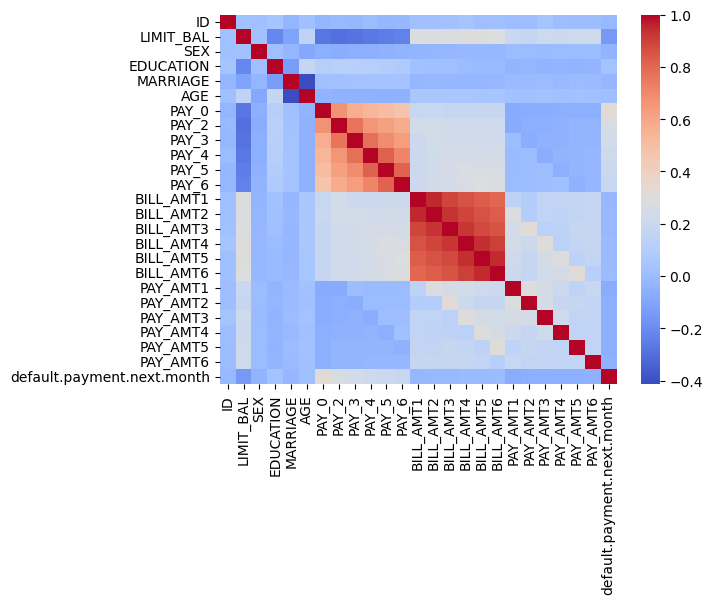

In [9]:
corr = df.corr(numeric_only=True)
corr["default.payment.next.month"].sort_values(ascending=False).round(2)
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")

Color meaning:

🔴 Red → strong positive correlation (+1)

🔵 Blue → negative correlation (−1)

⚪ Light → weak / no linear relationship (≈0)

The red pay block --> if someone is late this month → they were likely late before --> strong correlation

BILL AMT block --> customers tend to carry similar debt month to month --> strong correlation

In [10]:
df[["PAY_0","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6"]].corr().round(2)

,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
PAY_0,1.00,0.67,0.57,0.54,0.51,0.47
PAY_2,0.67,1.00,0.77,0.66,0.62,0.58
PAY_3,0.57,0.77,1.00,0.78,0.69,0.63
PAY_4,0.54,0.66,0.78,1.00,0.82,0.72
PAY_5,0.51,0.62,0.69,0.82,1.00,0.82
PAY_6,0.47,0.58,0.63,0.72,0.82,1.00


# Feature 1 — Worst delay (risk ceiling)

What is the worst repayment delay they had in the last 6 months?

In [11]:
df["max_delay"] = df[["PAY_0","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6"]].max(axis=1)

# Feature 2 - Average delay

In [12]:
df["avg_delay"] = df[["PAY_0","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6"]].mean(axis=1)

# Feature 3 - Delay trend

In [13]:
df["delay_trend"] = df["PAY_0"] - df["PAY_6"]

In [14]:
df[["max_delay","avg_delay","delay_trend","default.payment.next.month"]].corr().round(2)

,max_delay,avg_delay,delay_trend,default.payment.next.month
max_delay,1.00,0.81,0.12,0.33
avg_delay,0.81,1.00,-0.10,0.28
delay_trend,0.12,-0.10,1.00,0.13
default.payment.next.month,0.33,0.28,0.13,1.00


- max_delay --> the worst payment delay a customer hadis strongly associated with default risk
- avg_delay --> customers who are generally late tend to default more
- delay_trend --> small correlation

Repayment delay severity is the dominant predictor of default, with both extreme delinquency and consistent late payment contributing to elevated risk, while worsening trends provide additional incremental signal.

# Logistic Regression

In [15]:
features = ["LIMIT_BAL","AGE","max_delay","avg_delay","delay_trend"]

In [16]:
X = df[features]
y = df['default.payment.next.month']

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn. model_selection import train_test_split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(random_state=42)

In [21]:
pred = model.predict(X_test)

In [22]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

In [23]:
accuracy_score(y_test, pred)

0.7945

In [24]:
confusion_matrix(y_test, pred)

array([[4457,  216],
       [1017,  310]])

Meaning	Value
- True Negatives (TN)	4457
- False Positives (FP)	216
- False Negatives (FN)	1017
- True Positives (TP)	310

Accuracy looks good only because most customers don't default.

In fact, the model missed 1017 customers and correctly identified only 310 defaulted customers. 

In [25]:
from sklearn.metrics import classification_report
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.81      0.95      0.88      4673
           1       0.59      0.23      0.33      1327

    accuracy                           0.79      6000
   macro avg       0.70      0.59      0.61      6000
weighted avg       0.76      0.79      0.76      6000



# Random Forest

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    class_weight="balanced")

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

In [27]:
y_pred_rf = rf.predict(X_test)

In [28]:
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.85      0.84      4673
           1       0.42      0.39      0.41      1327

    accuracy                           0.75      6000
   macro avg       0.63      0.62      0.62      6000
weighted avg       0.74      0.75      0.74      6000

[[3960  713]
 [ 804  523]]


Big improvement in the performance, now 39% of defaulters were detected
Accuracy dropped, because the model is now willing to flag more risky customers

In [29]:
pd.Series(
    rf.feature_importances_,
    index=X_train.columns).sort_values(ascending=False)

AGE            0.335227
LIMIT_BAL      0.274652
avg_delay      0.179483
max_delay      0.136902
delay_trend    0.073736
dtype: float64

Model importance suggests demographic and financial capacity variables (age and credit limit) interact with repayment behavior to determine default risk, while engineered delay features capture core behavioral signals.

Project Conclusion — Credit Default Prediction

This project aimed to predict whether a credit card customer will default next month using behavioral and financial data.

Exploratory analysis showed that repayment history is the strongest risk signal, with default probability increasing sharply once customers become two or more months late. Recent payment behavior proved more predictive than older history, indicating a strong recency effect in financial risk.

To capture customer behavior, repayment history variables were summarized into engineered features (max_delay, avg_delay, and delay_trend), reducing redundancy while preserving predictive information.

Two models were evaluated:

- Logistic Regression achieved higher overall accuracy (0.79) but detected only 23% of defaulters, indicating conservative predictions biased toward the majority class.

- Random Forest captured nonlinear relationships and improved default detection recall to 39%, at the cost of slightly lower accuracy (0.75). This tradeoff is preferable in credit risk contexts where missing defaulters is more costly than issuing additional warnings.

Feature importance analysis showed that repayment behavior, credit limit, and age jointly influence risk, suggesting default emerges from interactions between financial capacity and payment habits rather than demographics alone.

Key takeaway:
Behavioral features derived from repayment patterns significantly improve risk detection, and model evaluation should prioritize recall and business impact over raw accuracy in imbalanced financial datasets.